# CEXI Model Tutorial

## Cellular EXchange Imaging (CEXI) Model 

### Authors: Jonathan and the CEXI Team
### Date: 2025 

## 1. Setup and Imports

In [24]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# Import the CEXI implementation
import utils_inverse_multidelta as cexi

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11


## 2. Understanding the CEXI Model Parameters

The CEXI model describes water diffusion in biological tissue with five key parameters:

| Parameter | Symbol | Units | Typical Range | Description |
|-----------|--------|-------|---------------|-------------|
| Cell radius | R | μm | 2-15 | Average cell size |
| Intracellular diffusivity | D<sub>i</sub> | ×10⁻⁹ m²/s | 0.5-1.5 | Water mobility inside cells |
| Extracellular diffusivity | D<sub>e</sub> | ×10⁻⁹ m²/s | 1.5-3.0 | Water mobility outside cells |
| Intracellular fraction | f | - | 0.4-0.8 | Volume fraction of intracellular space |
| Membrane permeability | κ | μm/s | 0-50 | Water exchange rate (>50 unstable) |

### Exchange Time Calculation:
- **Intracellular exchange rate**: k_i = (1-f) × 3κ/R
- **Exchange time**: τ_ie = 1/k_i = R / (3κ(1-f))

In [25]:
# Define typical tissue parameters
params_tissue = {
    'R': 5.0,      # μm - typical lymphocyte cell radius
    'Di': 1.0e-9,  # m²/s - intracellular diffusivity (restricted)
    'De': 2.0e-9,  # m²/s - extracellular diffusivity (hindered)
    'f': 0.65,     # intracellular volume fraction
    'kappa': 25.0  # μm/s - membrane permeability
}

# Calculate exchange times 
f = params_tissue['f']
R = params_tissue['R']
kappa = params_tissue['kappa']

# k_i = (1-f) * 3κ/R
k_i = (1 - f) * 3 * kappa / R  # s⁻¹
tau_ie = 1000 / k_i  # ms

print(f"Exchange parameters:")
print(f"  k_i = (1-f) × 3κ/R = {k_i:.2f} s⁻¹")
print(f"  τ_ie = {tau_ie:.1f} ms")
print(f"  → Intracellular water exchanges in ~{tau_ie:.0f} ms")

# Create a simple acquisition protocol
b_values = np.concatenate([[0], np.linspace(100, 2000, 20)])
protocol_simple = cexi.Protocol(
    bvals=b_values,
    delta=0.010,  # 10 ms gradient duration
    tdiff=0.040   # 40 ms diffusion time
)

print(f"\nProtocol: {len(b_values)} b-values from {b_values[0]:.0f} to {b_values[-1]:.0f} s/mm²")
print(f"Timing: δ={protocol_simple.delta[0]*1000:.0f}ms, Δ={protocol_simple.tdiff[0]*1000:.0f}ms")

Exchange parameters:
  k_i = (1-f) × 3κ/R = 5.25 s⁻¹
  τ_ie = 190.5 ms
  → Intracellular water exchanges in ~190 ms

Protocol: 21 b-values from 0 to 2000 s/mm²
Timing: δ=10ms, Δ=40ms


## 3. Part 1: Individual Compartment Signals

### 3.1 Intracellular Compartment - Restricted Diffusion in Spheres

Water molecules trapped inside cells experience **restricted diffusion**. The signal depends on:
- Cell size (R): Smaller cells → LESS attenuation (molecules hit walls sooner)
- Diffusion time (Δ): Longer time → more restriction effects

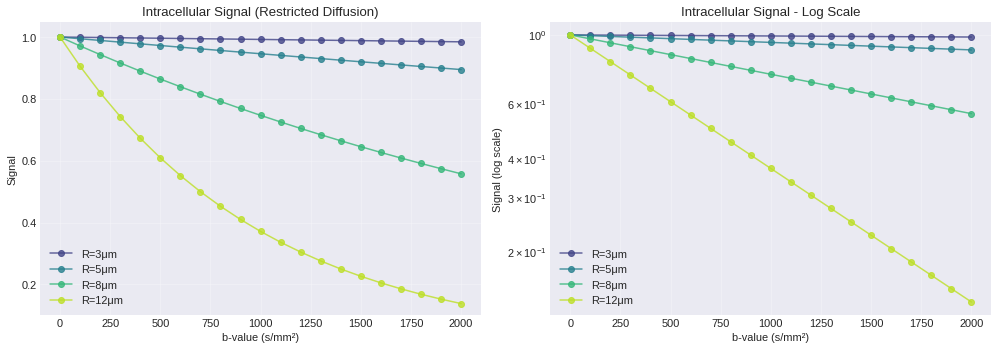

Smaller cells (R=3μm) → LESS signal attenuation
Larger cells (R=12μm) → MORE signal attenuation
Non-exponential decay (curved in log plot)

Signal at b=2000 s/mm²:
  R= 3μm: S = 0.9844
  R= 5μm: S = 0.8947
  R= 8μm: S = 0.5576
  R=12μm: S = 0.1379


In [30]:
# Test different cell sizes to verify correct physics
cell_sizes = [3.0, 5.0, 8.0, 12.0]  # μm
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cell_sizes)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, R in enumerate(cell_sizes):
    signal = cexi.SPHERE_sig(R, params_tissue['Di'], protocol_simple, normalize=True)
    ax1.plot(b_values, signal, 'o-', color=colors[i], label=f'R={R:.0f}μm', alpha=0.8)
    ax2.semilogy(b_values, signal, 'o-', color=colors[i], label=f'R={R:.0f}μm', alpha=0.8)

ax1.set_xlabel('b-value (s/mm²)')
ax1.set_ylabel('Signal')
ax1.set_title('Intracellular Signal (Restricted Diffusion)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.1, 1.05])

ax2.set_xlabel('b-value (s/mm²)') 
ax2.set_ylabel('Signal (log scale)')
ax2.set_title('Intracellular Signal - Log Scale')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Smaller cells (R=3μm) → LESS signal attenuation")
print("Larger cells (R=12μm) → MORE signal attenuation")
print("Non-exponential decay (curved in log plot)")

# Quantitative verification
print(f"\nSignal at b=2000 s/mm²:")
for R in cell_sizes:
    sig = cexi.SPHERE_sig(R, params_tissue['Di'], protocol_simple, normalize=True)[-1]
    print(f"  R={R:2.0f}μm: S = {sig:.4f}")

### 3.2 Extracellular Compartment - Hindered Diffusion

Water in the extracellular space experiences **hindered diffusion** - simple exponential decay:

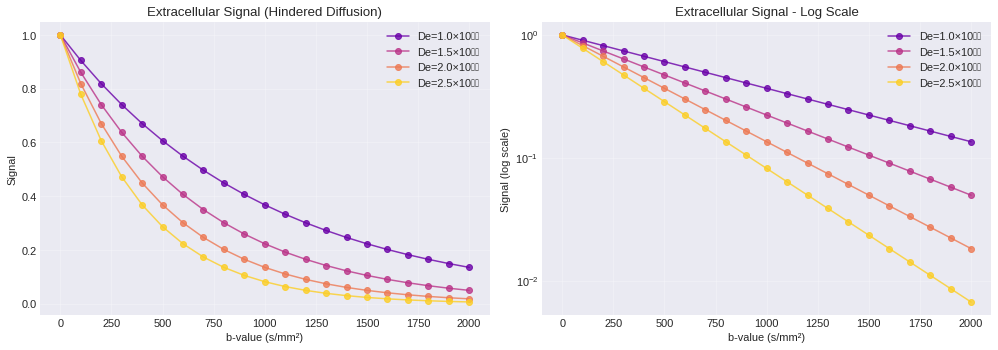

Higher diffusivity → Faster signal decay
Exponential decay (straight line in log plot)
Much stronger attenuation than restricted intracellular

Signal at b=2000 s/mm² (extracellular):
  De=1.0×10⁻⁹ m²/s: S = 0.135335
  De=1.5×10⁻⁹ m²/s: S = 0.049787
  De=2.0×10⁻⁹ m²/s: S = 0.018316
  De=2.5×10⁻⁹ m²/s: S = 0.006738


In [31]:
# Generate extracellular signals with different diffusivities
De_values = [1.0e-9, 1.5e-9, 2.0e-9, 2.5e-9]  # m²/s
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(De_values)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, De in enumerate(De_values):
    # Simple exponential decay: S = exp(-b*De)
    signal = np.exp(-b_values * De * 1e6)  # Convert De to mm²/s
    ax1.plot(b_values, signal, 'o-', color=colors[i], 
             label=f'De={De*1e9:.1f}×10⁻⁹', alpha=0.8)
    ax2.semilogy(b_values, signal, 'o-', color=colors[i], 
                 label=f'De={De*1e9:.1f}×10⁻⁹', alpha=0.8)

ax1.set_xlabel('b-value (s/mm²)')
ax1.set_ylabel('Signal')
ax1.set_title('Extracellular Signal (Hindered Diffusion)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('b-value (s/mm²)')
ax2.set_ylabel('Signal (log scale)')
ax2.set_title('Extracellular Signal - Log Scale')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Higher diffusivity → Faster signal decay")
print("Exponential decay (straight line in log plot)")
print("Much stronger attenuation than restricted intracellular")

# Verification
print(f"\nSignal at b=2000 s/mm² (extracellular):")
for De in De_values:
    signal_at_2000 = np.exp(-2000 * De * 1e6)
    print(f"  De={De*1e9:.1f}×10⁻⁹ m²/s: S = {signal_at_2000:.6f}")

## 4. Part 2: Combined CEXI Signal with Exchange

### 4.1 Effect of Membrane Permeability 

With the corrected exchange rate formula: **k_i = (1-f) × 3κ/R**

Impermeable (κ=0.1): k_i = 0.02 s⁻¹, τ_ie = 47619.0 ms
Low (κ=5): k_i = 1.05 s⁻¹, τ_ie = 952.4 ms
Medium (κ=25): k_i = 5.25 s⁻¹, τ_ie = 190.5 ms
High (κ=45): k_i = 9.45 s⁻¹, τ_ie = 105.8 ms


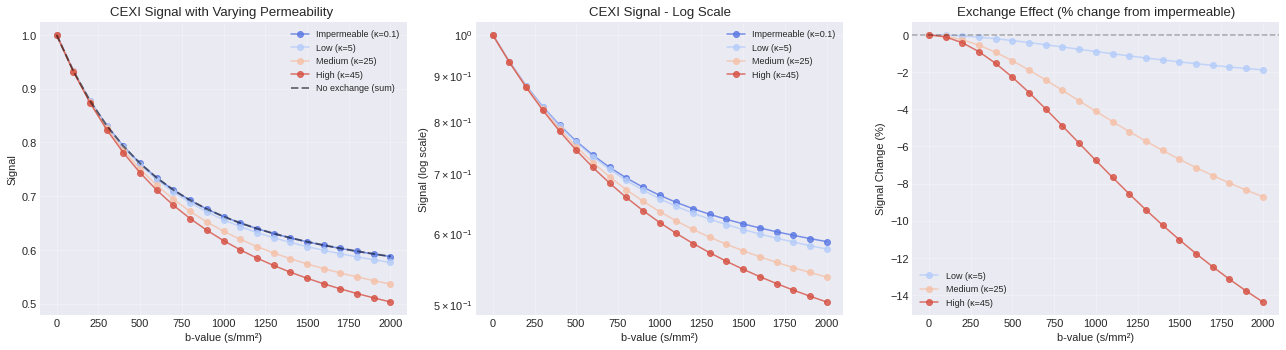


💡 Key observations:
Higher permeability → More signal attenuation
Exchange effects clearly visible (5-15% changes)
Effects strongest at intermediate to high b-values


In [32]:
# Test different permeability values
kappa_values = [0.1, 5, 25, 45]  # μm/s (keeping below 50 for stability)
kappa_labels = ['Impermeable (κ=0.1)', 'Low (κ=5)', 'Medium (κ=25)', 'High (κ=45)']
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(kappa_values)))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Calculate reference signals
signal_intra_only = params_tissue['f'] * cexi.SPHERE_sig(
    params_tissue['R'], params_tissue['Di'], protocol_simple, normalize=True
)
signal_extra_only = (1 - params_tissue['f']) * np.exp(
    -b_values * params_tissue['De'] * 1e6
)
signal_no_exchange = signal_intra_only + signal_extra_only

# Store first signal for difference calculation
signal_impermeable = None

for i, (kappa, label) in enumerate(zip(kappa_values, kappa_labels)):
    # Generate CEXI signal with varying permeability
    signal_cexi = cexi.CEXI_sig(
        params_tissue['R'], params_tissue['Di'], params_tissue['De'],
        params_tissue['f'], kappa, protocol_simple, normalize=True
    )
    
    if i == 0:
        signal_impermeable = signal_cexi.copy()
    
    ax1.plot(b_values, signal_cexi, 'o-', color=colors[i], label=label, alpha=0.8)
    ax2.semilogy(b_values, signal_cexi, 'o-', color=colors[i], label=label, alpha=0.8)
    
    # Calculate exchange time 
    k_i = (1 - params_tissue['f']) * 3 * kappa * 1e-6 / (params_tissue['R'] * 1e-6)  # s⁻¹
    tau_ie = 1000 / k_i  # ms
    print(f"{label}: k_i = {k_i:.2f} s⁻¹, τ_ie = {tau_ie:.1f} ms")

# Add reference lines
ax1.plot(b_values, signal_no_exchange, 'k--', 
         label='No exchange (sum)', alpha=0.5, linewidth=2)

ax1.set_xlabel('b-value (s/mm²)')
ax1.set_ylabel('Signal')
ax1.set_title('CEXI Signal with Varying Permeability ')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('b-value (s/mm²)')
ax2.set_ylabel('Signal (log scale)')
ax2.set_title('CEXI Signal - Log Scale')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot signal difference from impermeable case
for i, (kappa, label) in enumerate(zip(kappa_values[1:], kappa_labels[1:])):
    signal_cexi = cexi.CEXI_sig(
        params_tissue['R'], params_tissue['Di'], params_tissue['De'],
        params_tissue['f'], kappa, protocol_simple, normalize=True
    )
    diff_percent = 100 * (signal_cexi - signal_impermeable) / signal_impermeable
    ax3.plot(b_values, diff_percent, 'o-', color=colors[i+1], label=label, alpha=0.8)

ax3.set_xlabel('b-value (s/mm²)')
ax3.set_ylabel('Signal Change (%)')
ax3.set_title('Exchange Effect (% change from impermeable)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.axhline(0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key observations:")
print("Higher permeability → More signal attenuation")
print("Exchange effects clearly visible (5-15% changes)")
print("Effects strongest at intermediate to high b-values")

### 4.2 Time-Dependent Effects

Exchange effects depend on diffusion time (Δ) - crucial for parameter estimation:

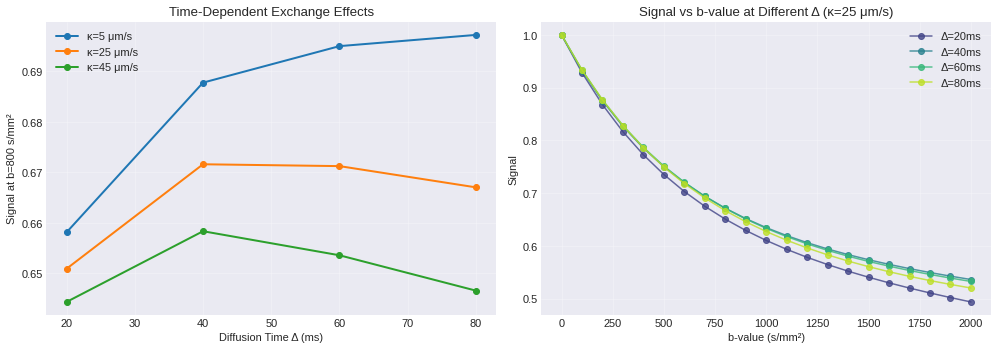

💡 Key observations:
Longer diffusion time → More exchange effects
Effect saturates when Δ >> exchange time
Multiple Δ values essential for separating restriction from exchange


In [33]:
# Create protocols with different diffusion times
tdiff_values = [0.020, 0.040, 0.060, 0.080]  # seconds
colors_td = plt.cm.viridis(np.linspace(0.2, 0.9, len(tdiff_values)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fixed b-value to see time dependence clearly
b_test = 800  # s/mm²

for kappa_test in [5, 25, 45]:
    signals_at_b = []
    
    for td in tdiff_values:
        protocol_td = cexi.Protocol(
            bvals=np.array([0, b_test]),
            delta=0.010,
            tdiff=td
        )
        
        signal = cexi.CEXI_sig(
            params_tissue['R'], params_tissue['Di'], params_tissue['De'],
            params_tissue['f'], kappa_test, protocol_td, normalize=True
        )
        signals_at_b.append(signal[1])  # Get signal at b=800
    
    ax1.plot(np.array(tdiff_values)*1000, signals_at_b, 'o-', 
             label=f'κ={kappa_test} μm/s', linewidth=2)

# Show full signal curves at different Δ
for i, td in enumerate(tdiff_values):
    protocol_td = cexi.Protocol(
        bvals=b_values,
        delta=0.010,
        tdiff=td
    )
    
    signal = cexi.CEXI_sig(
        params_tissue['R'], params_tissue['Di'], params_tissue['De'],
        params_tissue['f'], 25.0, protocol_td, normalize=True  # Fixed κ=25
    )
    
    ax2.plot(b_values, signal, 'o-', color=colors_td[i], 
             label=f'Δ={td*1000:.0f}ms', alpha=0.8)

ax1.set_xlabel('Diffusion Time Δ (ms)')
ax1.set_ylabel(f'Signal at b={b_test} s/mm²')
ax1.set_title('Time-Dependent Exchange Effects')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('b-value (s/mm²)')
ax2.set_ylabel('Signal')
ax2.set_title('Signal vs b-value at Different Δ (κ=25 μm/s)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Key observations:")
print("Longer diffusion time → More exchange effects")
print("Effect saturates when Δ >> exchange time")
print("Multiple Δ values essential for separating restriction from exchange")

## 5. Part 3: Model Fitting

### 5.1 Generate Synthetic Data with Noise

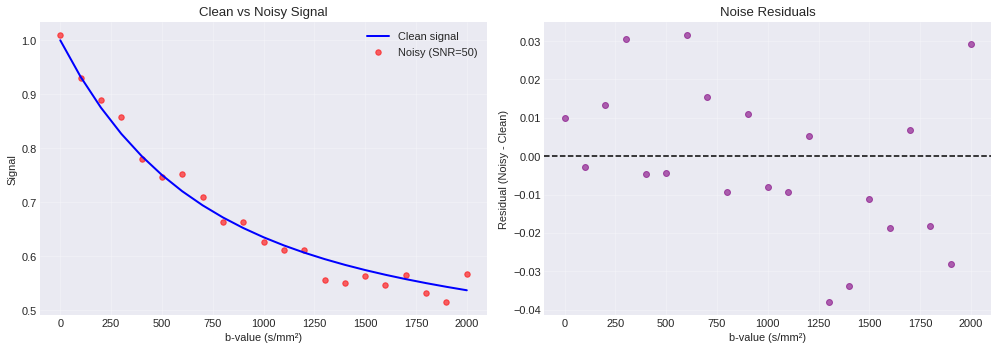

Noise statistics:
  Standard deviation: 0.0194
  SNR at b=0: 51.4
  SNR at b=2000: 27.6


In [34]:
# Generate clean signal
signal_clean = cexi.CEXI_sig(
    params_tissue['R'], params_tissue['Di'], params_tissue['De'],
    params_tissue['f'], params_tissue['kappa'], protocol_simple
)

# Add realistic noise (SNR = 50)
np.random.seed(42)  # For reproducibility
signal_noisy = cexi.generate_noisy_signal(signal_clean, SNR=50, noise_type='rician')

# Visualize clean vs noisy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(b_values, signal_clean, 'b-', label='Clean signal', linewidth=2)
ax1.scatter(b_values, signal_noisy, color='red', s=30, alpha=0.6, label='Noisy (SNR=50)')
ax1.set_xlabel('b-value (s/mm²)')
ax1.set_ylabel('Signal')
ax1.set_title('Clean vs Noisy Signal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Show residuals
residuals = signal_noisy - signal_clean
ax2.scatter(b_values, residuals, color='purple', alpha=0.6)
ax2.axhline(0, color='k', linestyle='--')
ax2.set_xlabel('b-value (s/mm²)')
ax2.set_ylabel('Residual (Noisy - Clean)')
ax2.set_title('Noise Residuals')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

noise_level = np.std(residuals)
print(f"Noise statistics:")
print(f"  Standard deviation: {noise_level:.4f}")
print(f"  SNR at b=0: {signal_clean[0]/noise_level:.1f}")
print(f"  SNR at b=2000: {signal_clean[-1]/noise_level:.1f}")

### 5.2 Fit the CEXI Model

In [35]:
# Define parameter bounds
bounds = {
    'R': (2.0, 15.0),       # μm
    'Di': (0.3e-9, 2.0e-9), # m²/s
    'De': (1.0e-9, 3.5e-9), # m²/s
    'f': (0.3, 0.85),       # fraction
    'kappa': (1.0, 50.0)    # μm/s (limited to stable range)
}

print("Starting CEXI model fitting ...")
print("Using 10 random initializations\n")

# Fit the model
fitted_params, fit_cost = cexi.fit_CEXI(
    signal_noisy, 
    protocol_simple, 
    bounds=bounds, 
    n_init=10
)

# Generate fitted signal
if fitted_params is not None:
    signal_fitted = cexi.CEXI_sig(
        fitted_params['R'], fitted_params['Di'], fitted_params['De'],
        fitted_params['f'], fitted_params['kappa'], protocol_simple
    )
    
    # Calculate R²
    ss_res = np.sum((signal_noisy - signal_fitted)**2)
    ss_tot = np.sum((signal_noisy - np.mean(signal_noisy))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    print("=" * 60)
    print("FITTING RESULTS")
    print("=" * 60)
    print(f"\n{'Parameter':<10} {'True':>10} {'Fitted':>10} {'Error':>10}")
    print("-" * 50)
    
    for key in params_tissue:
        true_val = params_tissue[key]
        fit_val = fitted_params[key]
        error = 100 * (fit_val - true_val) / true_val
        
        if key in ['Di', 'De']:
            print(f"{key:<10} {true_val*1e9:>10.2f} {fit_val*1e9:>10.2f} {error:>9.1f}%")
        else:
            print(f"{key:<10} {true_val:>10.2f} {fit_val:>10.2f} {error:>9.1f}%")
    
    # Calculate exchange times with fitted parameters
    k_i_fitted = (1 - fitted_params['f']) * 3 * fitted_params['kappa'] / fitted_params['R']
    tau_ie_fitted = 1000 / k_i_fitted
    
    k_i_true = (1 - params_tissue['f']) * 3 * params_tissue['kappa'] / params_tissue['R']
    tau_ie_true = 1000 / k_i_true
    
    print(f"\nExchange time :")
    print(f"  True τ_ie: {tau_ie_true:.1f} ms")
    print(f"  Fitted τ_ie: {tau_ie_fitted:.1f} ms")
    
    print(f"\nFit quality:")
    print(f"  RMSE: {fit_cost:.4f}")
    print(f"  R²: {r_squared:.4f}")
else:
    print("Fitting failed!")
    signal_fitted = None

Starting CEXI model fitting ...
Using 10 random initializations

FITTING RESULTS

Parameter        True     Fitted      Error
--------------------------------------------------
R                5.00       3.83     -23.3%
Di               1.00       1.09       9.1%
De               2.00       1.97      -1.7%
f                0.65       0.64      -0.9%
kappa           25.00      38.84      55.4%

Exchange time :
  True τ_ie: 190.5 ms
  Fitted τ_ie: 92.5 ms

Fit quality:
  RMSE: 0.0178
  R²: 0.9841


### 5.3 Visualize Fitting Results

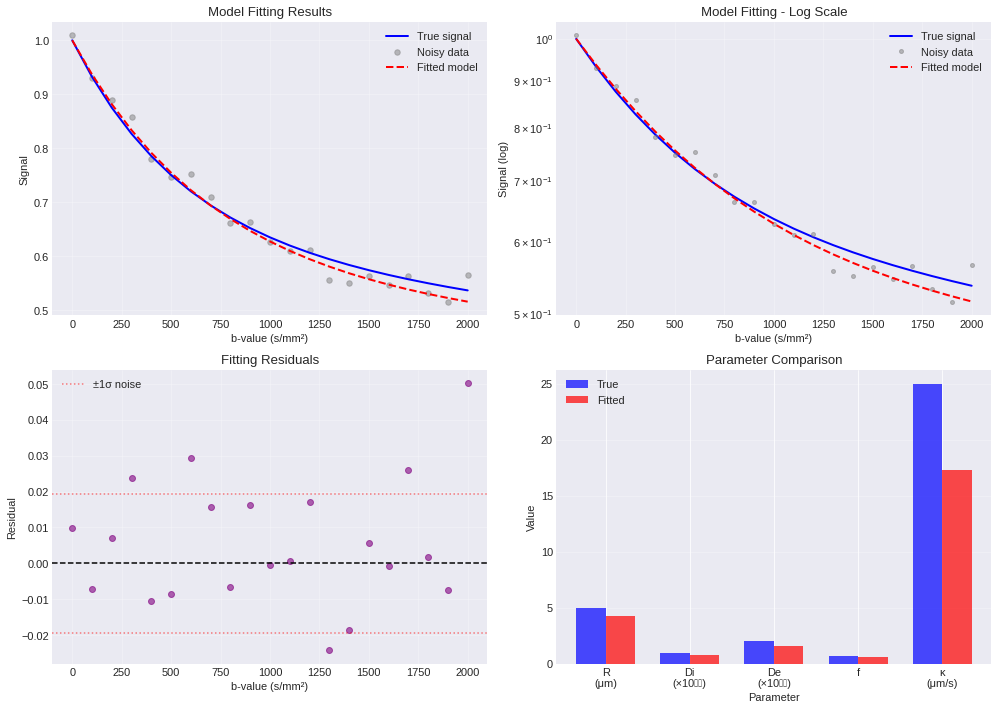


💡 Parameter identifiability analysis:

Parameter estimation accuracy (best to worst):
  f: 11.5% error - Good
  R: 15.4% error - Good
  Di: 20.0% error - Good
  De: 22.8% error - Moderate
  kappa: 30.8% error - Poor

Average parameter error: 20.1%


In [27]:
if signal_fitted is not None:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Signal comparison
    ax1.plot(b_values, signal_clean, 'b-', label='True signal', linewidth=2)
    ax1.scatter(b_values, signal_noisy, color='gray', s=30, alpha=0.5, label='Noisy data')
    ax1.plot(b_values, signal_fitted, 'r--', label='Fitted model', linewidth=2)
    ax1.set_xlabel('b-value (s/mm²)')
    ax1.set_ylabel('Signal')
    ax1.set_title('Model Fitting Results')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Log scale
    ax2.semilogy(b_values, signal_clean, 'b-', label='True signal', linewidth=2)
    ax2.semilogy(b_values, signal_noisy, 'o', color='gray', alpha=0.5, markersize=4, label='Noisy data')
    ax2.semilogy(b_values, signal_fitted, 'r--', label='Fitted model', linewidth=2)
    ax2.set_xlabel('b-value (s/mm²)')
    ax2.set_ylabel('Signal (log)')
    ax2.set_title('Model Fitting - Log Scale')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Residuals
    residuals_fit = signal_noisy - signal_fitted
    ax3.scatter(b_values, residuals_fit, color='purple', alpha=0.6)
    ax3.axhline(0, color='k', linestyle='--')
    ax3.axhline(noise_level, color='r', linestyle=':', alpha=0.5, label='±1σ noise')
    ax3.axhline(-noise_level, color='r', linestyle=':', alpha=0.5)
    ax3.set_xlabel('b-value (s/mm²)')
    ax3.set_ylabel('Residual')
    ax3.set_title('Fitting Residuals')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Parameter comparison
    param_names = ['R', 'Di', 'De', 'f', 'kappa']
    param_labels = ['R\n(μm)', 'Di\n(×10⁻⁹)', 'De\n(×10⁻⁹)', 'f', 'κ\n(μm/s)']
    
    true_vals = [params_tissue[p] if p not in ['Di', 'De'] else params_tissue[p]*1e9 
                 for p in param_names]
    fitted_vals = [fitted_params[p] if p not in ['Di', 'De'] else fitted_params[p]*1e9 
                   for p in param_names]
    
    x = np.arange(len(param_names))
    width = 0.35
    
    bars1 = ax4.bar(x - width/2, true_vals, width, label='True', color='blue', alpha=0.7)
    bars2 = ax4.bar(x + width/2, fitted_vals, width, label='Fitted', color='red', alpha=0.7)
    
    ax4.set_xlabel('Parameter')
    ax4.set_ylabel('Value')
    ax4.set_title('Parameter Comparison')
    ax4.set_xticks(x)
    ax4.set_xticklabels(param_labels)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Parameter identifiability analysis
    print("\n💡 Parameter identifiability analysis:")
    
    param_errors = {}
    for key in params_tissue:
        true_val = params_tissue[key]
        fit_val = fitted_params[key]
        param_errors[key] = abs(100 * (fit_val - true_val) / true_val)
    
    sorted_errors = sorted(param_errors.items(), key=lambda x: x[1])
    
    print("\nParameter estimation accuracy (best to worst):")
    for param, error in sorted_errors:
        quality = "Excellent" if error < 10 else "Good" if error < 20 else "Moderate" if error < 30 else "Poor"
        print(f"  {param}: {error:.1f}% error - {quality}")
    
    avg_error = np.mean(list(param_errors.values()))
    print(f"\nAverage parameter error: {avg_error:.1f}%")
    

## 6. Part 4: Protocol Optimization

### 6.1 Compare Single vs Multi-Delta Protocols

In [28]:
# Create multi-delta protocol
b_multi = []
delta_multi = []
tdiff_multi = []

# Three different diffusion times
for td, d in zip([0.025, 0.045, 0.065], [0.008, 0.010, 0.012]):
    for b in [0, 300, 600, 900, 1200, 1500]:
        b_multi.append(b)
        delta_multi.append(d)
        tdiff_multi.append(td)

protocol_multi = cexi.Protocol(
    bvals=np.array(b_multi),
    delta=np.array(delta_multi),
    tdiff=np.array(tdiff_multi)
)

print(f"Single-Δ protocol: {len(protocol_simple.b)} measurements, 1 timing")
print(f"Multi-Δ protocol: {len(protocol_multi.b)} measurements, 3 timings\n")

# Generate signals for both protocols
signal_single = cexi.CEXI_sig(
    params_tissue['R'], params_tissue['Di'], params_tissue['De'],
    params_tissue['f'], params_tissue['kappa'], protocol_simple
)

signal_multi = cexi.CEXI_sig(
    params_tissue['R'], params_tissue['Di'], params_tissue['De'],
    params_tissue['f'], params_tissue['kappa'], protocol_multi
)

# Add noise
np.random.seed(43)
signal_single_noisy = cexi.generate_noisy_signal(signal_single, SNR=30)
signal_multi_noisy = cexi.generate_noisy_signal(signal_multi, SNR=30)

# Fit both
print("Fitting single-Δ protocol...")
params_single_fit, cost_single = cexi.fit_CEXI(
    signal_single_noisy, protocol_simple, bounds=bounds, n_init=5
)

print("Fitting multi-Δ protocol...\n")
params_multi_fit, cost_multi = cexi.fit_CEXI(
    signal_multi_noisy, protocol_multi, bounds=bounds, n_init=5
)

# Compare results
print("="*60)
print("PROTOCOL COMPARISON")
print("="*60)

print(f"\n{'Parameter':<10} {'True':>10} {'Single-Δ':>12} {'Multi-Δ':>12}")
print("-"*60)

for key in params_tissue:
    true_val = params_tissue[key]
    single_val = params_single_fit[key] if params_single_fit else np.nan
    multi_val = params_multi_fit[key] if params_multi_fit else np.nan
    
    if key in ['Di', 'De']:
        print(f"{key:<10} {true_val*1e9:>10.2f} {single_val*1e9:>12.2f} {multi_val*1e9:>12.2f}")
    else:
        print(f"{key:<10} {true_val:>10.2f} {single_val:>12.2f} {multi_val:>12.2f}")

# Calculate average errors
if params_single_fit and params_multi_fit:
    errors_single = [abs(100*(params_single_fit[k]-params_tissue[k])/params_tissue[k]) 
                     for k in params_tissue]
    errors_multi = [abs(100*(params_multi_fit[k]-params_tissue[k])/params_tissue[k]) 
                    for k in params_tissue]
    
    print(f"\nAverage error:")
    print(f"  Single-Δ: {np.mean(errors_single):.1f}%")
    print(f"  Multi-Δ: {np.mean(errors_multi):.1f}%")
    
    improvement = (np.mean(errors_single) - np.mean(errors_multi)) / np.mean(errors_single) * 100
    
    if np.mean(errors_multi) < np.mean(errors_single):
        print(f"\n Multi-Δ protocol improves accuracy by {improvement:.0f}%!")
    else:
        print(f"\n Single-Δ performed better (may be due to noise realization)")

print("\n💡 Protocol design insights:")
print("• Multiple Δ values help separate restriction from exchange")
print("• Permeability (κ) estimation particularly benefits from time-dependent data")
print("• Exchange time can be better constrained with multi-Δ")

Single-Δ protocol: 21 measurements, 1 timing
Multi-Δ protocol: 18 measurements, 3 timings

Fitting single-Δ protocol...
Fitting multi-Δ protocol...

PROTOCOL COMPARISON

Parameter        True     Single-Δ      Multi-Δ
------------------------------------------------------------
R                5.00         3.67         4.36
Di               1.00         0.86         2.00
De               2.00         1.45         1.00
f                0.65         0.55         0.46
kappa           25.00         6.18        11.51

Average error:
  Single-Δ: 31.7%
  Multi-Δ: 49.1%

 Single-Δ performed better (may be due to noise realization)

💡 Protocol design insights:
• Multiple Δ values help separate restriction from exchange
• Permeability (κ) estimation particularly benefits from time-dependent data
• Exchange time can be better constrained with multi-Δ


## 7. Summary and Conclusions

### CEXI vs Ball-Sphere Comparison:

| Aspect | Ball-Sphere | CEXI                |
|--------|-------------|---------------------|
| Membranes | Impermeable | Permeable with k_i = (1-f)×3κ/R |
| Exchange | None | Kärger model with conservation |
| Parameters | R, f, Di, De | R, f, Di, De, κ |
| Best for | No exchange | Permeable membranes |
| Key bias | Overestimates R when exchange exists | Stable up to κ=50 μm/s |

### Protocol Recommendations:

1. **Multi-delta protocols**: Essential for separating restriction from exchange
2. **b-value range**: 0-3000 s/mm² for good SNR and contrast
3. **Diffusion times**: Multiple Δ values (20-80 ms) to probe exchange
4. **Permeability range**: Keep κ < 50 μm/s for stable fitting

---

### References:

1. Gardier R, et. al. Cellular Exchange Imaging (CEXI): Evaluation of a diffusion model including water exchange in cells using numerical phantoms of permeable spheres. Magn Reson Med. 2023 Oct;90(4):1625-1640. doi: 10.1002/mrm.29720. Epub 2023 Jun 6. PMID: 37279007.

2. Kärger (1985) - NMR self-diffusion studies of exchange
